In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
SEED = 42

import os
import random

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_PATH = "/kaggle/input/datasets/cvbnqq/data-1/train_2.csv"
# DATA_PATH = "train_2.csv"


df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(5))

shape: (485082, 24)
columns: ['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии', 'РТО']


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74209339.11


In [4]:
df[(df["Год"] == 2022)]

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО


In [5]:
df[(df["Год"] == 2023) & (df["Месяц"] == 1)].head(1)


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22


rolling_mean

# Инфляция 
------------------------------------------------------------------------------------------------

Логика следующая:

1. Посчитаем медианную выручку по всей сети для каждого месяца. Ее рост и будет идеальным отражением инфляции + масштаба рынка.

2. **Дефлируем трейн:**  
   Разделим историческое РТО на этот индекс. Модель будет учиться предсказывать «чистые физические объемы продаж» в ценах базового месяца.

3. **Инфлируем тест:**  
   При финальном прогнозе на Март 2025 года мы возьмем предсказание модели и умножим его на спрогнозированный индекс инфляции Марта.

In [8]:
df_macro = df[df['РТО'] > 0].copy()
macro = df_macro.groupby(['Год', 'Месяц'])['РТО'].median().reset_index()
macro = macro.sort_values(['Год', 'Месяц']).reset_index(drop=True)
macro

,Год,Месяц,РТО
0,2023,1,61536441.58
1,2023,2,59697426.57
2,2023,3,67368328.13
3,2023,4,68210235.48
4,2023,5,72007592.97
5,2023,6,70882433.96
6,2023,7,73209133.39
7,2023,8,72461796.10
8,2023,9,69107223.21
9,2023,10,71046935.37


In [9]:
base_rto = macro['РТО'].iloc[0]
macro['inflation_idx'] = macro['РТО'] / base_rto
macro

,Год,Месяц,РТО,inflation_idx
0,2023,1,61536441.58,1.000000
1,2023,2,59697426.57,0.970115
2,2023,3,67368328.13,1.094771
3,2023,4,68210235.48,1.108453
4,2023,5,72007592.97,1.170162
5,2023,6,70882433.96,1.151877
6,2023,7,73209133.39,1.189687
7,2023,8,72461796.10,1.177543
8,2023,9,69107223.21,1.123029
9,2023,10,71046935.37,1.154551


In [10]:
inflation_dict = dict(zip(zip(macro['Год'], macro['Месяц']), macro['inflation_idx']))
inflation_dict

{(2023, 1): 1.0,
 (2023, 2): 0.9701150251333724,
 (2023, 3): 1.0947712672403764,
 (2023, 4): 1.1084527107620252,
 (2023, 5): 1.1701617955335792,
 (2023, 6): 1.1518773614468722,
 (2023, 7): 1.1896874682756071,
 (2023, 8): 1.177542838673838,
 (2023, 9): 1.123029239839253,
 (2023, 10): 1.1545505971065284,
 (2023, 11): 1.1346802921521808,
 (2023, 12): 1.3404341185826494,
 (2024, 1): 1.1336977277001656,
 (2024, 2): 1.1581444864235193,
 (2024, 3): 1.2905399183142043,
 (2024, 4): 1.2753149307142633,
 (2024, 5): 1.3531127668757217,
 (2024, 6): 1.338432589946323,
 (2024, 7): 1.3808713339319483,
 (2024, 8): 1.3342337585975181,
 (2024, 9): 1.2655862016127972,
 (2024, 10): 1.3088341743858112,
 (2024, 11): 1.2961932219675807,
 (2024, 12): 1.5134765125949294,
 (2025, 1): 1.3051227818493563,
 (2025, 2): 1.2635794533051385}

In [11]:
feb_2025_idx = inflation_dict[(2025, 2)]
mar_2024_idx = inflation_dict[(2024, 3)]
feb_2024_idx = inflation_dict[(2024, 2)]

inflation_dict[(2025, 3)] = feb_2025_idx * (mar_2024_idx / feb_2024_idx)
inflation_dict

{(2023, 1): 1.0,
 (2023, 2): 0.9701150251333724,
 (2023, 3): 1.0947712672403764,
 (2023, 4): 1.1084527107620252,
 (2023, 5): 1.1701617955335792,
 (2023, 6): 1.1518773614468722,
 (2023, 7): 1.1896874682756071,
 (2023, 8): 1.177542838673838,
 (2023, 9): 1.123029239839253,
 (2023, 10): 1.1545505971065284,
 (2023, 11): 1.1346802921521808,
 (2023, 12): 1.3404341185826494,
 (2024, 1): 1.1336977277001656,
 (2024, 2): 1.1581444864235193,
 (2024, 3): 1.2905399183142043,
 (2024, 4): 1.2753149307142633,
 (2024, 5): 1.3531127668757217,
 (2024, 6): 1.338432589946323,
 (2024, 7): 1.3808713339319483,
 (2024, 8): 1.3342337585975181,
 (2024, 9): 1.2655862016127972,
 (2024, 10): 1.3088341743858112,
 (2024, 11): 1.2961932219675807,
 (2024, 12): 1.5134765125949294,
 (2025, 1): 1.3051227818493563,
 (2025, 2): 1.2635794533051385,
 (2025, 3): 1.408027878704241}

In [12]:
df['РТО_nominal'] = df['РТО']
df['inflation_multiplier'] = df.apply(lambda row: inflation_dict.get((int(row['Год']), int(row['Месяц'])), 1.0), axis=1)
df['РТО'] = df['РТО'] / df['inflation_multiplier']

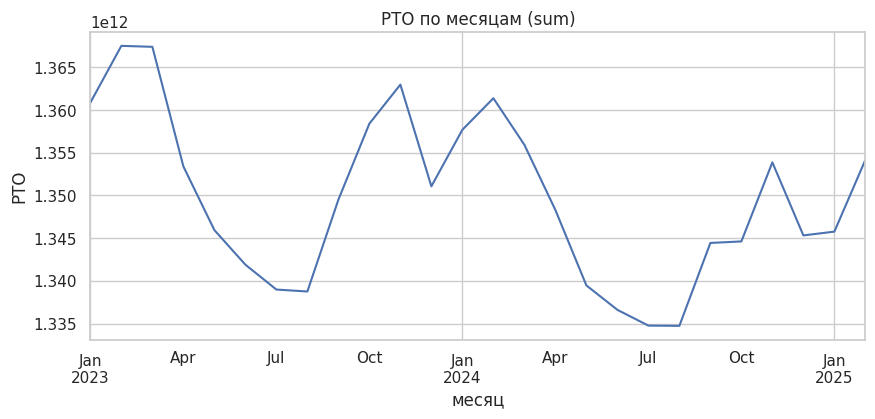

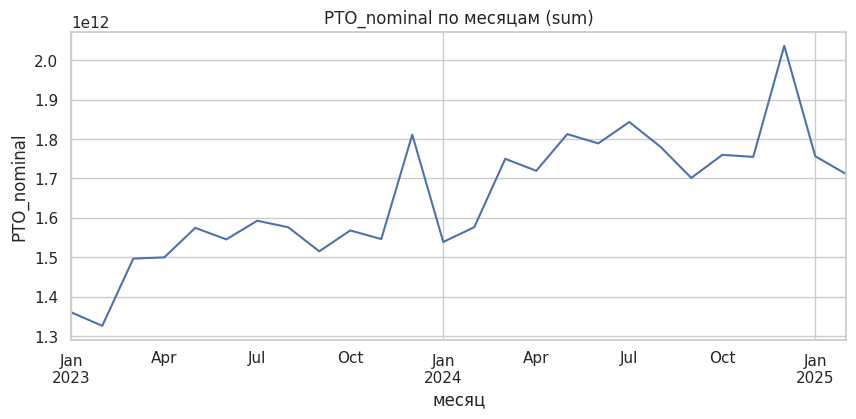

In [13]:
def plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО", agg="sum"):
    data = df[[year_col, month_col, target_col]].copy()
    data["_date"] = pd.to_datetime(
        data[year_col].astype(int).astype(str)
        + "-"
        + data[month_col].astype(int).astype(str).str.zfill(2)
        + "-01",
        errors="coerce",
    )
    data = data.dropna(subset=["_date"])

    grouped = data.groupby("_date")[target_col]
    if agg == "sum":
        series = grouped.sum()
    elif agg == "mean":
        series = grouped.mean()
    elif agg == "median":
        series = grouped.median()
    else:
        raise ValueError("agg должен быть: sum, mean или median")

    series = series.sort_index()
    ax = series.plot(figsize=(10, 4))
    ax.set_title(f"{target_col} по месяцам ({agg})")
    ax.set_xlabel("месяц")
    ax.set_ylabel(target_col)
    plt.show()
    return series
rto_series = plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО", agg="sum")
rto_series = plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО_nominal", agg="sum")

------------------------------------------------------------------------------------------------

In [ ]:
# df['РТО_nominal'] = df['РТО']
# df['inflation_multiplier'] = df.apply(lambda row: inflation_dict.get((int(row['Год']), int(row['Месяц'])), 1.0), axis=1)
# df['РТО'] = df['РТО'] / df['inflation_multiplier']


#

In [6]:
mean_cols = [c for c in df.columns if "Среднее" in str(c)]
mean_cols

['Среднее количество промо товаров в чеке',
 'Среднее количество товаров в чеке',
 'Среднее количество отмен']

In [ ]:
import numpy as np
import pandas as pd
import calendar

def create_features_for_month(df, target_year, target_month):
    """
    Функция собирает обучающие или тестовые признаки для конкретного целевого месяца.
    Вся история строго ПОСЛЕ target_year и target_month игнорируется, чтобы не было ликов.
    """
    
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Торговая площадь, категориальный',
        'Дата открытия, категориальный', 'Количество домохозяйств', 'Количество касс',
        'Трафик пеший, в час', 'Трафик авто, в час',
        'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 
        'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)'
    ]
    base_df = df[static_cols].drop_duplicates(subset=['new_id']).copy()
    
    

    target_time_value = target_year * 12 + target_month
    history_before_target = df[(df['Год'] * 12 + df['Месяц']) < target_time_value]
    
    metrics_to_agg = [
        'Среднее количество промо товаров в чеке',
        'Среднее количество товаров в чеке',
        'Среднее количество отмен'
    ]

    shop_profile = history_before_target.groupby('new_id')[metrics_to_agg].mean().reset_index()
    shop_profile['hist_is_high_cancel'] = (np.log1p(shop_profile['Среднее количество отмен'].fillna(0)) > 6).astype(int)

    for col in metrics_to_agg:
        shop_profile[f'log_{col}'] = np.log1p(shop_profile[col].fillna(0))

    cols_to_keep = ['new_id', 'hist_is_high_cancel']
    cols_to_keep.extend([f'log_{c}' for c in metrics_to_agg])
    

    base_df = base_df.merge(shop_profile[cols_to_keep], on='new_id', how='left')

    for col in cols_to_keep:
        if col != 'new_id':
            base_df[col] = base_df[col].fillna(0)
    
    #cross-features
    base_df['Регион_Кластер'] = base_df['Регион'].astype(str) + "_" + base_df['hist_is_high_cancel'].astype(str)
    base_df['Город_Кластер'] = base_df['Населенный пункт'].astype(str) + "_" + base_df['hist_is_high_cancel'].astype(str)
    
    #lag rto
    def get_historical_rto(shift_months):
        total_months = target_year * 12 + (target_month - 1) - shift_months
        hist_y = total_months // 12
        hist_m = (total_months % 12) + 1
        
        hist_slice = df[(df['Год'] == hist_y) & (df['Месяц'] == hist_m)][['new_id', 'РТО']].copy()
        hist_slice['РТО'] = np.log1p(hist_slice['РТО'].fillna(0))
        hist_slice.columns = ['new_id', f'log_rto_lag_{shift_months}']
        return hist_slice

    base_df = base_df.merge(get_historical_rto(1), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(2), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(6), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(12), on='new_id', how='left')


    #  #----------------------------
    # base_df['rto_yoy_ratio'] = base_df['rto_lag_1'] / (base_df['rto_lag_12'] + 1)
    # base_df['rto_yoy_diff'] = base_df['rto_lag_1'] - base_df['rto_lag_12']

    # region_lag1_mean = base_df.groupby('Регион')['rto_lag_1'].transform('mean') 
    # base_df['rto_lag_1_region_mean'] = region_lag1_mean 
    # base_df['rto_vs_region'] = base_df['rto_lag_1'] / (region_lag1_mean + 1)
    #  #----------------------------

    #rolling rto 
    history_before_target = history_before_target.copy()
    history_before_target['log_РТО'] = np.log1p(history_before_target['РТО'].fillna(0))
    def get_rolling_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        
        # agg_df = window_df.groupby('new_id')['РТО'].agg(['mean', 'std', 'min', 'max']).reset_index()
        agg_df = window_df.groupby('new_id')['log_РТО'].agg(['mean', 'std', 'min', 'max']).reset_index()
        agg_df.columns = [
            'new_id', 
            f'log_rto_roll_{window_months}m_mean', 
            f'log_rto_roll_{window_months}m_std',
            f'log_rto_roll_{window_months}m_min',
            f'log_rto_roll_{window_months}m_max'
        ]
        return agg_df
    
    base_df = base_df.merge(get_rolling_stats(3), on='new_id', how='left')
    base_df = base_df.merge(get_rolling_stats(6), on='new_id', how='left')
    
    roll_cols = [c for c in base_df.columns if 'log_rto' in c]
    for c in roll_cols:
        base_df[c] = base_df[c].fillna(0)

    #  #----------------------------
    def get_rolling_other_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        
        agg_df = window_df.groupby('new_id')[['Среднее количество промо товаров в чеке', 'Среднее количество отмен']].mean().reset_index()
        agg_df.columns = [
            'new_id', 
            f'promo_roll_{window_months}m_mean', 
            f'cancels_roll_{window_months}m_mean'
        ]
        return agg_df

    base_df = base_df.merge(get_rolling_other_stats(3), on='new_id', how='left')
    base_df['promo_roll_3m_mean'] = base_df['promo_roll_3m_mean'].fillna(0)
    base_df['cancels_roll_3m_mean'] = base_df['cancels_roll_3m_mean'].fillna(0)
    #  #----------------------------
    
    rto_lag_1_linear = np.expm1(base_df['log_rto_lag_1'])
    base_df['log_rto_per_household'] = np.log1p(rto_lag_1_linear / (base_df['Количество домохозяйств'] + 1))
    base_df['log_rto_per_cashbox'] = np.log1p(rto_lag_1_linear / (base_df['Количество касс'] + 1))
    base_df['traffic_per_household'] = base_df['Трафик пеший, в час'] / (base_df['Количество домохозяйств'] + 1)

    # base_df['rto_per_household'] = base_df['rto_lag_1'] / (base_df['Количество домохозяйств'] + 1)
    # base_df['rto_per_cashbox'] = base_df['rto_lag_1'] / (base_df['Количество касс'] + 1)
    # base_df['traffic_per_household'] = base_df['Трафик пеший, в час'] / (base_df['Количество домохозяйств'] + 1)

    base_df['Месяц_сезон'] = int(target_month)

    # #----------------------------
    store_age = history_before_target.groupby('new_id').size().reset_index(name='store_age_months')
    base_df = base_df.merge(store_age, on='new_id', how='left')
    base_df['store_age_months'] = base_df['store_age_months'].fillna(0)
    base_df['is_new_store'] = (base_df['store_age_months'] <= 6).astype(int)
    #----------------------------


    # #----------------------------
    base_df['days_in_target_month'] = calendar.monthrange(target_year, target_month)[1]
    
    abs_target_month = target_year * 12 + target_month - 1
    lag1_abs = abs_target_month - 1
    y_lag1 = lag1_abs // 12
    m_lag1 = (lag1_abs % 12) + 1
    
    days_in_lag1_month = calendar.monthrange(y_lag1, m_lag1)[1]

    # # РТО в среднем за день в прошлом месяце
    # base_df['rto_lag_1_per_day'] = base_df['rto_lag_1'] / days_in_lag1_month
    # base_df['log_rto_lag_1_per_day'] = np.log1p(rto_lag_1_linear / days_in_lag1_month)
    
    # # Теоретическое РТО на целевой месяц (если продажи в день останутся как в прошлом месяце)
    # base_df['expected_rto_base'] = base_df['rto_lag_1_per_day'] * base_df['days_in_target_month']
    
    return base_df

In [8]:
df.head(3)

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92


In [9]:
import pandas as pd
import numpy as np

all_months = []

unique_periods = df[['Год', 'Месяц']].drop_duplicates().sort_values(by=['Год',  'Месяц'])

for _, row in unique_periods.iterrows():
    year = int(row['Год'])
    month = int(row[ 'Месяц'])
    
    X_m = create_features_for_month(df, year, month)
    
    y_m = df[(df['Год'] == year) & (df[ 'Месяц'] == month)][['new_id', 'РТО']]
    # y_m = df[(df['Год'] == year) & (df['Месяц'] == month)][['new_id', 'РТО', 'РТО_nominal']]
    
    merged = X_m.merge(y_m, on='new_id', how='inner')
    merged['time_id'] = year * 100 + month # 202301, 202302 и т.д.
    
    all_months.append(merged)
    print(f"Собран {year}-{month:02d} | Строк: {len(merged)}")

master_df = pd.concat(all_months, ignore_index=True)

cat_features = [
    'Регион', 'Населенный пункт', 'Торговая площадь, категориальный',
    'Дата открытия, категориальный', 'Регион_Кластер', 'Город_Кластер'
]
for col in cat_features:
    master_df[col] = master_df[col].fillna('Missing').astype(str)

print(f"len Dataset: {len(master_df)}")

Собран 2023-01 | Строк: 18657
Собран 2023-02 | Строк: 18657
Собран 2023-03 | Строк: 18657
Собран 2023-04 | Строк: 18657
Собран 2023-05 | Строк: 18657
Собран 2023-06 | Строк: 18657
Собран 2023-07 | Строк: 18657
Собран 2023-08 | Строк: 18657
Собран 2023-09 | Строк: 18657
Собран 2023-10 | Строк: 18657
Собран 2023-11 | Строк: 18657
Собран 2023-12 | Строк: 18657
Собран 2024-01 | Строк: 18657
Собран 2024-02 | Строк: 18657
Собран 2024-03 | Строк: 18657
Собран 2024-04 | Строк: 18657
Собран 2024-05 | Строк: 18657
Собран 2024-06 | Строк: 18657
Собран 2024-07 | Строк: 18657
Собран 2024-08 | Строк: 18657
Собран 2024-09 | Строк: 18657
Собран 2024-10 | Строк: 18657
Собран 2024-11 | Строк: 18657
Собран 2024-12 | Строк: 18657
Собран 2025-01 | Строк: 18657
Собран 2025-02 | Строк: 18657
len Dataset: 485082


In [10]:
master_df.head(5)

,new_id,Регион,Населенный пункт,"Торговая площадь, категориальный","Дата открытия, категориальный",Количество домохозяйств,Количество касс,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),hist_is_high_cancel,log_Среднее количество промо товаров в чеке,log_Среднее количество товаров в чеке,log_Среднее количество отмен,Регион_Кластер,Город_Кластер,log_rto_lag_1,log_rto_lag_2,log_rto_lag_6,log_rto_lag_12,log_rto_roll_3m_mean,log_rto_roll_3m_std,log_rto_roll_3m_min,log_rto_roll_3m_max,log_rto_roll_6m_mean,log_rto_roll_6m_std,log_rto_roll_6m_min,log_rto_roll_6m_max,promo_roll_3m_mean,cancels_roll_3m_mean,log_rto_per_household,log_rto_per_cashbox,traffic_per_household,Месяц_сезон,store_age_months,is_new_store,days_in_target_month,log_rto_lag_1_per_day,РТО,time_id
0,0,Ярославская обл,Ярославль г,Большой,Новый,3775,10,138,73,1,0,0,0,3,1,0.0,0.0,0.0,0.0,Ярославская обл_0.0,Ярославль г_0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036547,1,0.0,1,31,0.0,74914754.22,202301
1,1,Челябинская обл,Магнитогорск г,Средний,Средний по возрасту,2627,8,143,443,2,0,1,5,4,1,0.0,0.0,0.0,0.0,Челябинская обл_0.0,Магнитогорск г_0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054414,1,0.0,1,31,0.0,31205203.83,202301
2,2,Татарстан Респ,Казань г,Маленький,Средний по возрасту,10652,8,176,335,1,8,0,4,9,6,0.0,0.0,0.0,0.0,Татарстан Респ_0.0,Казань г_0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016521,1,0.0,1,31,0.0,59621632.75,202301
3,3,Самарская обл,Подбельск с,Маленький,Средний по возрасту,162,9,0,0,1,1,0,0,1,0,0.0,0.0,0.0,0.0,Самарская обл_0.0,Подбельск с_0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1,0.0,1,31,0.0,49041021.82,202301
4,4,Калужская обл,Калуга г,Средний,Средний по возрасту,4127,4,127,82,1,4,1,2,5,0,0.0,0.0,0.0,0.0,Калужская обл_0.0,Калуга г_0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.030766,1,0.0,1,31,0.0,64058902.67,202301


In [11]:
time_ids = sorted(master_df['time_id'].unique())
len(time_ids)

26

In [12]:
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

def run_cv(master_df, val_cnt, time_ids, cat_features, drop_cols, model_params, use_inflation=False, inflation_dict=None):
    val_time_ids = time_ids[-val_cnt:] 
    
    fold_scores = []
    models = []
    
    for val_time in val_time_ids:
        print(f"Валидация на месяце: {val_time}")
        
        train_df = master_df[master_df['time_id'] < val_time].copy()
        val_df = master_df[master_df['time_id'] == val_time].copy()
        
        X_train, y_train_raw = train_df.drop(columns=drop_cols), train_df['РТО']
        X_val, y_val_raw = val_df.drop(columns=drop_cols), val_df['РТО']
        
        y_train_log = np.log1p(y_train_raw)
        y_val_log = np.log1p(y_val_raw)
        
        train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
        val_pool = Pool(X_val, y_val_log, cat_features=cat_features)
        
        model = CatBoostRegressor(**model_params)
        
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        preds_log = model.predict(X_val)
        preds_raw = np.expm1(preds_log)
    
        if use_inflation and inflation_dict is not None:
            val_year, val_month = int(val_time) // 100, int(val_time) % 100
            val_macro_idx = inflation_dict[(val_year, val_month)]
            preds_final = preds_raw * val_macro_idx
            best_mape = mean_absolute_percentage_error(val_df['РТО_nominal'], preds_final)
        else:
            best_mape = mean_absolute_percentage_error(y_val_raw, preds_raw)
        
        fold_scores.append(best_mape)
        models.append(model)
        
        print(f"MAPE для {val_time}: {best_mape * 100:.3f}%\n")
    
    mean_mape = np.mean(fold_scores) * 100
    std_mape = np.std(fold_scores) * 100
    
    print(f"Средний MAPE по всем фолдам: {mean_mape:.3f}% ± {std_mape:.3f}%")
    
    return models, fold_scores

In [13]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=['new_id', 'РТО', 'time_id'],
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202411
0:	learn: 0.4590777	test: 0.4586381	best: 0.4586381 (0)	total: 46ms	remaining: 2m 17s
500:	learn: 0.0969151	test: 0.0610032	best: 0.0610032 (500)	total: 13.4s	remaining: 1m 6s
1000:	learn: 0.0931161	test: 0.0597110	best: 0.0597098 (981)	total: 27.3s	remaining: 54.6s
1500:	learn: 0.0912389	test: 0.0589761	best: 0.0589759 (1498)	total: 41.7s	remaining: 41.6s
2000:	learn: 0.0899106	test: 0.0585887	best: 0.0585887 (1999)	total: 56.1s	remaining: 28s
2500:	learn: 0.0887230	test: 0.0583175	best: 0.0583175 (2500)	total: 1m 10s	remaining: 14.1s
2999:	learn: 0.0877511	test: 0.0582106	best: 0.0582102 (2998)	total: 1m 25s	remaining: 0us
bestTest = 0.05821015701
bestIteration = 2998
Shrink model to first 2999 iterations.
MAPE для 202411: 3.794%

Валидация на месяце: 202412
0:	learn: 0.4590217	test: 0.4994078	best: 0.4994078 (0)	total: 35.5ms	remaining: 1m 46s
500:	learn: 0.0956705	test: 0.0669022	best: 0.0669022 (500)	total: 13.8s	remaining: 1m 8s
1000:	learn: 0.0919056	

Средний MAPE по всем фолдам: 4.610% ± 0.601% + more features & more iter (2000->3000)

Средний MAPE по всем фолдам: 4.272% ± 0.391% + more features & more iter (2000->3000)

Средний MAPE по всем фолдам: 4.507% ± 0.796% + rolling

Средний MAPE по всем фолдам: 5.097% ± 0.870% without rolling

Средний MAPE по всем фолдам: 5.407% ± 1.298% + инфляция

Средний MAPE по всем фолдам: 5.139% ± 0.885% without rolling

Средний MAPE по всем фолдам: 7.507% ± 2.777% just rndm prompt

In [20]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool


drop_cols = ['new_id', 'РТО', 'time_id']
# drop_cols = ['new_id', 'РТО', 'РТО_nominal', 'time_id']
X_train_full = master_df.drop(columns=drop_cols)
y_train_full_log = np.log1p(master_df['РТО'])

full_train_pool = Pool(X_train_full, y_train_full_log, cat_features=cat_features)


final_model = CatBoostRegressor(
    iterations=3000, 
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE', #better optimaze MAPE 
    random_seed=42,
    verbose=500,
    l2_leaf_reg=5,
    task_type = "GPU",
    # thread_count = -1
)

final_model.fit(full_train_pool)

target_year = 2025 
target_month = 3   

test_df = create_features_for_month(df, target_year, target_month)

for col in cat_features:
    test_df[col] = test_df[col].fillna('Missing').astype(str)

submit_ids = test_df['new_id']

X_test = test_df.drop(columns=['new_id'])


test_preds_log = final_model.predict(X_test)

# mar_2025_idx = inflation_dict[(2025, 3)]
# test_preds_raw = np.expm1(test_preds_log) * mar_2025_idx
test_preds_raw = np.expm1(test_preds_log)

submission = pd.DataFrame({
    'new_id': submit_ids,
    'rto': test_preds_raw
})

filename = f'submission0.csv'
submission.to_csv(filename, index=False)

'done'

0:	learn: 0.4603625	total: 36.9ms	remaining: 1m 50s
500:	learn: 0.0934608	total: 15s	remaining: 1m 14s
1000:	learn: 0.0896694	total: 30.5s	remaining: 1m
1500:	learn: 0.0879062	total: 46.2s	remaining: 46.1s
2000:	learn: 0.0866679	total: 1m 2s	remaining: 31s
2500:	learn: 0.0857164	total: 1m 17s	remaining: 15.5s
2999:	learn: 0.0848245	total: 1m 33s	remaining: 0us


'done'

In [21]:
importance = final_model.get_feature_importance()

feature_importances = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
feature_importances

,Feature,Importance
41,log_rto_lag_1_per_day,65.053479
37,Месяц_сезон,9.755058
20,log_rto_lag_1,4.014744
5,Количество касс,3.470176
28,log_rto_roll_6m_mean,1.758778
1,Населенный пункт,1.575536
27,log_rto_roll_3m_max,1.507751
2,"Торговая площадь, категориальный",1.384609
24,log_rto_roll_3m_mean,1.243288
18,Регион_Кластер,0.903034


In [ ]:
feature_importances

,Feature,Importance
20,rto_lag_1,52.702307
35,Месяц_сезон,11.832339
24,rto_roll_3m_mean,7.665095
5,Количество касс,3.590917
27,rto_roll_3m_max,3.412316
26,rto_roll_3m_min,3.367505
28,rto_roll_6m_mean,2.027366
2,"Торговая площадь, категориальный",1.688641
33,rto_per_cashbox,1.364855
0,Регион,1.179819


In [162]:
feature_importances

,Feature,Importance
45,rto_lag_1_per_day,29.801022
46,expected_rto_base,28.561828
41,Месяц_сезон,9.185591
20,rto_lag_1,9.123674
5,Количество касс,3.521604
32,rto_roll_6m_mean,1.842230
2,"Торговая площадь, категориальный",1.627696
28,rto_roll_3m_mean,1.446449
0,Регион,1.246271
31,rto_roll_3m_max,1.132070
